# Safety Experiment Results Visualization

This notebook visualizes the results from the safety classification experiment.
Results are loaded from JSONL files in `data/safety_experiment/`.

In [7]:
import json
from pathlib import Path
from collections import defaultdict

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Configuration

Specify which datasets, models, and conditions to include in the visualization.

In [8]:
# Base path for results
RESULTS_DIR = Path("../data/safety_experiment")

# Datasets to include (None = all available)
DATASETS = ["annotated_intents", "wildguardmix", "xstest"]

# Models to include (None = all available)
# Fine-tuned models will have names like "meta-llama_Llama-3.1-8B-Instruct"
MODELS = None  # Set to None to include all models, or filter specific ones

# Conditions to include (None = all available)
# Vanilla conditions: vanilla_classification, vanilla_generation, vanilla_with_human_intent, vanilla_with_model_intent
# Fine-tuned conditions: finetuned_generation (intent+harm), finetuned_classification (harm only)
# Baseline: llamaguard_classification (LlamaGuard native safety classification)
CONDITIONS = [
    "vanilla_classification",
    "vanilla_generation", 
    "vanilla_with_human_intent",
    "finetuned_generation",
    "llamaguard_classification",
]

# Display names for conditions (used in all plots)
CONDITION_NAMES = {
    "vanilla_classification": "Vanilla Classification",
    "vanilla_generation": "Vanilla Generation",
    "vanilla_with_human_intent": "Vanilla + Human Intent",
    "vanilla_with_model_intent": "Vanilla + Model Intent",
    "finetuned_generation": "Fine-tuned Generation",
    "finetuned_classification": "Fine-tuned Classification",
    "llamaguard_classification": "LlamaGuard",
}

# Consistent color palette for conditions across all graphs (keyed by display name)
CONDITION_COLORS = {
    "Vanilla Classification": "#66c2a5",      # teal
    "Vanilla Generation": "#fc8d62",          # orange
    "Vanilla + Human Intent": "#8da0cb",      # blue
    "Vanilla + Model Intent": "#e78ac3",      # pink
    "Fine-tuned Generation": "#a6d854",       # green
    "Fine-tuned Classification": "#ffd92f",   # yellow
    "LlamaGuard": "#e5c494",                  # tan
}

## Load Results

In [9]:
def compute_metrics(results: list[dict]) -> dict:
    """Compute metrics from a list of result dictionaries."""
    tp = fp = tn = fn = 0
    
    for r in results:
        true_harm = r.get("true_harm_binary")
        pred_harm = r.get("predicted_harm")
        
        if true_harm is None or pred_harm is None:
            continue
            
        true_lower = true_harm.lower()
        pred_lower = pred_harm.lower()
        
        if true_lower == "harmful" and pred_lower == "harmful":
            tp += 1
        elif true_lower == "safe" and pred_lower == "harmful":
            fp += 1
        elif true_lower == "safe" and pred_lower == "safe":
            tn += 1
        elif true_lower == "harmful" and pred_lower == "safe":
            fn += 1
    
    total = tp + fp + tn + fn
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "total": total,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }


def load_results(results_dir: Path, datasets=None, models=None, conditions=None) -> pd.DataFrame:
    """Load all results matching the specified filters."""
    records = []
    
    # Get all dataset directories
    dataset_dirs = [d for d in results_dir.iterdir() if d.is_dir()]
    
    for dataset_dir in dataset_dirs:
        dataset_name = dataset_dir.name
        
        # Filter datasets
        if datasets is not None and dataset_name not in datasets:
            continue
        
        # Get all JSONL files
        for jsonl_file in dataset_dir.glob("*.jsonl"):
            # Parse filename: {model}_{condition}.jsonl
            filename = jsonl_file.stem
            
            # Find condition by checking known conditions
            known_conditions = [
                "vanilla_classification", "vanilla_generation",
                "vanilla_with_human_intent", "vanilla_with_model_intent",
                "finetuned_generation", "finetuned_classification",
                "llamaguard_classification"
            ]
            
            condition = None
            model_name = None
            for cond in known_conditions:
                if filename.endswith(f"_{cond}"):
                    condition = cond
                    model_name = filename[:-len(f"_{cond}")]
                    break
            
            if condition is None:
                continue
            
            # Filter models and conditions
            if models is not None and model_name not in models:
                continue
            if conditions is not None and condition not in conditions:
                continue
            
            # Load and compute metrics
            results = []
            with open(jsonl_file, "r") as f:
                for line in f:
                    results.append(json.loads(line))
            
            metrics = compute_metrics(results)
            
            # Map condition to display name
            display_condition = CONDITION_NAMES.get(condition, condition)
            
            records.append({
                "dataset": dataset_name,
                "model": model_name,
                "condition": display_condition,
                **metrics
            })
    
    return pd.DataFrame(records)


# Load results
df = load_results(RESULTS_DIR, datasets=DATASETS, models=MODELS, conditions=CONDITIONS)
print(f"Loaded {len(df)} result sets")
df

Loaded 13 result sets


,dataset,model,condition,accuracy,precision,recall,f1,total,tp,fp,tn,fn
0,annotated_intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla + Human Intent,0.690058,0.826087,0.457831,0.589147,171,38,8,80,45
1,annotated_intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla Classification,0.653061,0.697674,0.441176,0.540541,147,30,13,66,38
2,annotated_intents,meta-llama_Llama-3.1-8B-Instruct,Fine-tuned Generation,0.730994,0.768116,0.638554,0.697368,171,53,16,72,30
3,annotated_intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla Generation,0.616766,0.648148,0.437500,0.522388,167,35,19,68,45
4,annotated_intents,meta-llama_Llama-Guard-3-8B,LlamaGuard,0.616279,0.800000,0.285714,0.421053,172,24,6,82,60
5,wildguardmix,meta-llama_Llama-3.1-8B-Instruct,Vanilla Classification,0.852034,0.854779,0.778894,0.815074,1426,465,79,750,132
6,wildguardmix,meta-llama_Llama-3.1-8B-Instruct,Fine-tuned Generation,0.877358,0.900147,0.814077,0.854951,1696,613,68,875,140
7,wildguardmix,meta-llama_Llama-3.1-8B-Instruct,Vanilla Generation,0.825016,0.830769,0.703583,0.761905,1543,432,88,841,182
8,wildguardmix,meta-llama_Llama-Guard-3-8B,LlamaGuard,0.824603,0.931818,0.652520,0.767551,1699,492,36,909,262
9,xstest,meta-llama_Llama-3.1-8B-Instruct,Vanilla Classification,0.857778,0.774194,0.960000,0.857143,450,192,56,194,8


## F1 Score on Annotated Intents Dataset

This chart focuses on the annotated_intents dataset with bars ordered by ascending F1 score.

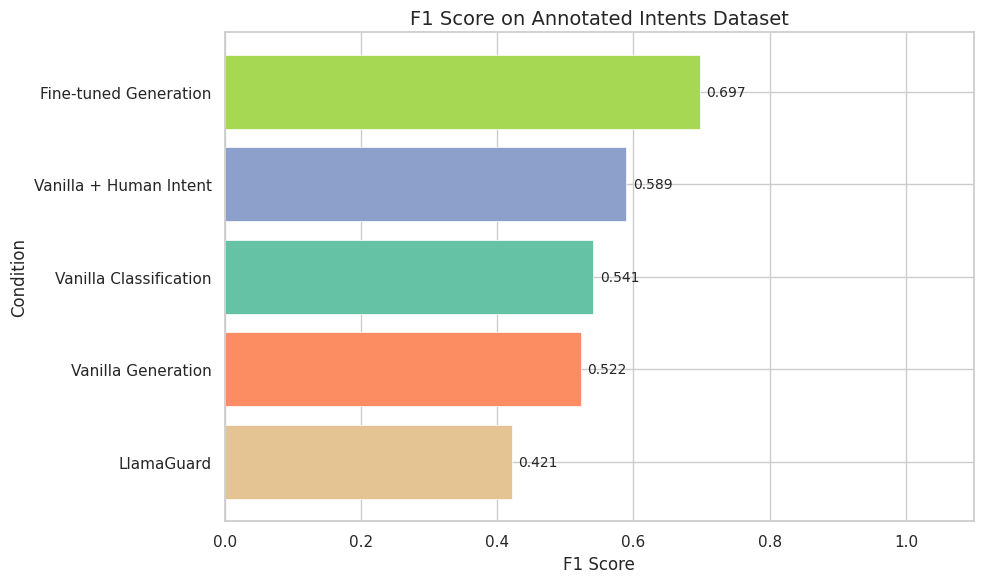

In [10]:
def plot_f1_single_dataset(df: pd.DataFrame, dataset: str, title: str = None):
    """Plot F1 scores for a single dataset, ordered by ascending F1."""
    df_filtered = df[df["dataset"] == dataset].copy()
    
    if df_filtered.empty:
        print(f"No data for dataset: {dataset}")
        return
    
    # Sort by F1 score ascending
    df_filtered = df_filtered.sort_values("f1", ascending=True)
    
    # Get colors in the same order as conditions after sorting
    colors = [CONDITION_COLORS.get(c, "#999999") for c in df_filtered["condition"]]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.barh(
        y=df_filtered["condition"],
        width=df_filtered["f1"],
        color=colors,
        edgecolor="white",
        linewidth=0.5
    )
    
    # Add value labels
    for bar, f1_val in zip(bars, df_filtered["f1"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f"{f1_val:.3f}", va="center", fontsize=10)
    
    ax.set_xlim(0, 1.1)
    ax.set_xlabel("F1 Score", fontsize=12)
    ax.set_ylabel("Condition", fontsize=12)
    ax.set_title(title or f"F1 Score on {dataset}", fontsize=14)
    
    plt.tight_layout()
    plt.show()


# Plot for annotated_intents dataset
plot_f1_single_dataset(df, "annotated_intents", "F1 Score on Annotated Intents Dataset")

## F1 Score Comparison Across All Datasets

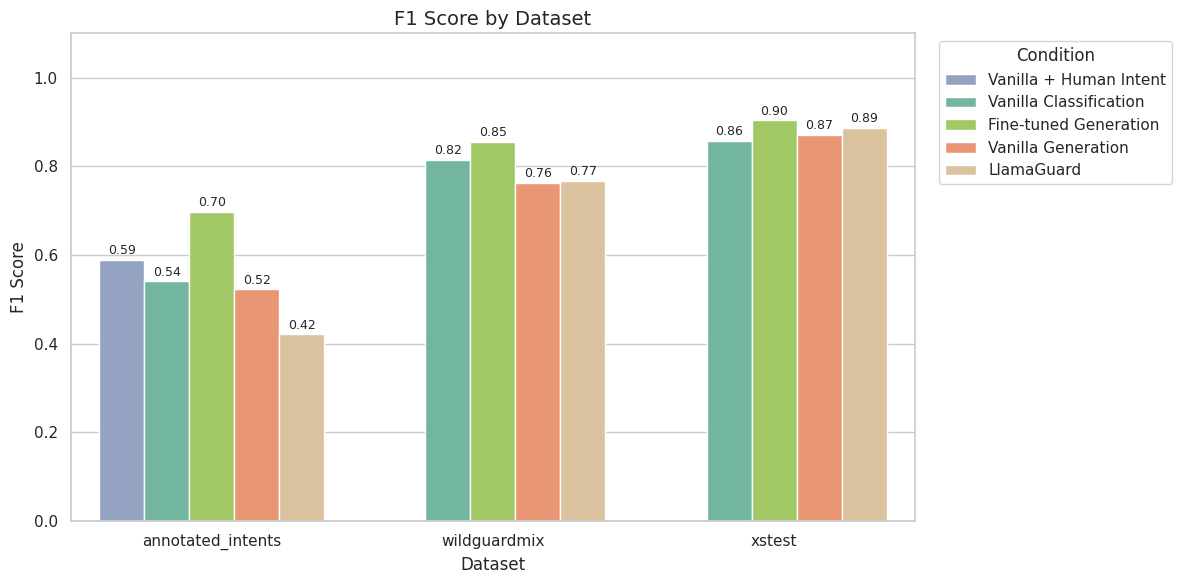

In [11]:
def plot_f1_by_dataset(df: pd.DataFrame, title: str = "F1 Score by Dataset"):
    """Plot F1 scores grouped by dataset with consistent colors."""
    if df.empty:
        print("No data to plot")
        return
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Get unique conditions in the data to build palette
    conditions_in_data = df["condition"].unique()
    palette = {c: CONDITION_COLORS.get(c, "#999999") for c in conditions_in_data}
    
    sns.barplot(
        data=df,
        x="dataset",
        y="f1",
        hue="condition",
        ax=ax,
        palette=palette
    )
    
    # Add value labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=9, padding=2)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Dataset", fontsize=12)
    ax.set_ylabel("F1 Score", fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")
    
    plt.tight_layout()
    plt.show()


plot_f1_by_dataset(df)

## Detailed Metrics Table

In [12]:
# Display detailed metrics
display_cols = ["dataset", "model", "condition", "accuracy", "precision", "recall", "f1", "total"]
df_display = df[display_cols].copy()

# Format numeric columns
for col in ["accuracy", "precision", "recall", "f1"]:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}")

df_display.sort_values(["dataset", "f1"], ascending=[True, False])

,dataset,model,condition,accuracy,precision,recall,f1,total
2,annotated_intents,meta-llama_Llama-3.1-8B-Instruct,Fine-tuned Generation,0.7310,0.7681,0.6386,0.6974,171
0,annotated_intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla + Human Intent,0.6901,0.8261,0.4578,0.5891,171
1,annotated_intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla Classification,0.6531,0.6977,0.4412,0.5405,147
3,annotated_intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla Generation,0.6168,0.6481,0.4375,0.5224,167
4,annotated_intents,meta-llama_Llama-Guard-3-8B,LlamaGuard,0.6163,0.8000,0.2857,0.4211,172
6,wildguardmix,meta-llama_Llama-3.1-8B-Instruct,Fine-tuned Generation,0.8774,0.9001,0.8141,0.8550,1696
5,wildguardmix,meta-llama_Llama-3.1-8B-Instruct,Vanilla Classification,0.8520,0.8548,0.7789,0.8151,1426
8,wildguardmix,meta-llama_Llama-Guard-3-8B,LlamaGuard,0.8246,0.9318,0.6525,0.7676,1699
7,wildguardmix,meta-llama_Llama-3.1-8B-Instruct,Vanilla Generation,0.8250,0.8308,0.7036,0.7619,1543
10,xstest,meta-llama_Llama-3.1-8B-Instruct,Fine-tuned Generation,0.9129,0.8927,0.9150,0.9037,448
